In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay




warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"clustered_data.csv")
# Print shape of dataset
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'clustered_data.csv'

In [ ]:
X = df.drop("cluster", axis=1) #dropping the target column which is 'cluster'
y = df["cluster"]

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay

from xgboost import XGBClassifier
from sklearn import metrics

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [ ]:
def evaluate_models(X, y, models):
    '''
    This function takes X, y and a dictionary of models
    It splits the data into Train-Test split
    Iterates through models and evaluates accuracy
    Returns a dataframe containing model names and their scores
    '''

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    import pandas as pd

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models_list = []
    scores = []

    # Iterate through models dictionary
    for name, model in models.items():

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Accuracy
        score = accuracy_score(y_test, y_pred)

        print(f'---- Score for {name} ----')
        print(score)
        print()

        models_list.append(name)
        scores.append(score)

    # Create report
    report = pd.DataFrame({
        "Model_Name": models_list,
        "Accuracy": scores
    })

    return report

In [ ]:
X.isnull().sum().sort_values(ascending=False)

,0
Age,0
Education,0
Marital Status,0
Parental Status,0
Children,0
Income,0
Total_Spending,0
Days_as_Customer,0
Recency,0
Wines,0


In [ ]:
X = X.dropna()
y = y[X.index]

In [ ]:
report = evaluate_models(X, y, models)

---- Score for Random Forest ----
0.9642857142857143

---- Score for Decision Tree ----
0.9397321428571429

---- Score for Gradient Boosting ----
0.9598214285714286

---- Score for Logistic Regression ----
0.8839285714285714

---- Score for K-Neighbors Classifier ----
0.8191964285714286

---- Score for XGBClassifier ----
0.9642857142857143

---- Score for AdaBoost Classifier ----
0.9419642857142857



In [ ]:
report.columns

Index(['Model_Name', 'Accuracy'], dtype='object')

In [ ]:
report.sort_values('Accuracy', ascending=False)

,Model_Name,Accuracy
0,Random Forest,0.964286
5,XGBClassifier,0.964286
2,Gradient Boosting,0.959821
6,AdaBoost Classifier,0.941964
1,Decision Tree,0.939732
3,Logistic Regression,0.883929
4,K-Neighbors Classifier,0.819196


In [ ]:
# Separate data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
994,68,2,0,1,2,64587.0,108.0,3056,49,66,0,16,0.0,6,20.0,1,1,4,2,0,3
2162,65,2,1,1,1,47320.0,414.0,3586,10,200,19,111,50.0,15,19.0,5,1,8,6,0,6
906,61,2,0,0,0,86429.0,1449.0,3269,10,464,28,556,29.0,18,37.0,7,4,7,0,1,2
572,44,1,0,1,1,38593.0,177.0,3338,42,51,12,49,17.0,24,24.0,4,1,3,3,0,8
1877,64,2,1,0,0,72905.0,1515.0,3208,52,407,81,445,120.5,81,126.5,3,7,9,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,53,2,1,1,2,44078.0,41.0,3059,17,24,1,10,2.0,0,4.0,2,0,3,2,0,5
1095,43,2,0,1,1,61825.0,424.0,3405,56,162,50,100,55.0,30,27.0,4,2,8,1,0,4
1130,71,3,1,1,1,67381.0,957.0,3579,67,815,8,53,11.0,0,70.0,2,2,9,4,1,7
1294,59,4,0,1,2,48918.0,62.0,2891,21,52,0,9,0.0,0,1.0,1,0,4,2,0,4


In [ ]:
best_lr_model = LogisticRegression(
    C = 1000,
    max_iter =  113,
    multi_class =  'auto',
    penalty =  'l2',
    solver =  'lbfgs')

In [ ]:
best_model = best_lr_model.fit(X_train,y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("Logistic regression")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Logistic regression
Accuracy Score value: 0.8795
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       179
           1       0.81      0.86      0.83       235
           2       0.98      0.95      0.96       258

    accuracy                           0.88       672
   macro avg       0.87      0.87      0.87       672
weighted avg       0.88      0.88      0.88       672



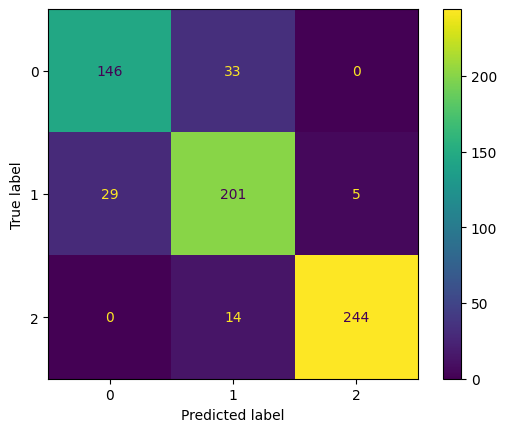

In [ ]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)